# Annotate Cell Type with curated marker gene list

In this notebook, we are going to annotate the single cell celltypes based on selected marker gene expression.

In [6]:
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt
import bbknn

# Data Processing

Filter and process the data following the [scanpy standard pipeline](https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html). End up with clustered cell ready to be annotated.

## Raw data filtering

In [2]:
# read and open the .h5 file generated from the cellranger count func
# and then aggregate the three replicates
samples = {
    "JCF-1": '../6-grammar_final/JCF-Gex-1-HT_final/outs/filtered_feature_bc_matrix.h5',
    "JCF-2": '../6-grammar_final/JCF-Gex-2-HT_final/outs/filtered_feature_bc_matrix.h5',
    "JCF-3": '../6-grammar_final/JCF-Gex-3-HT_final/outs/filtered_feature_bc_matrix.h5'
}
adatas = {}

for sample_id, path in samples.items():
    sample_adata = sc.read_10x_h5(path)
    sample_adata.var_names_make_unique()
    adatas[sample_id] = sample_adata

adata = ad.concat(adatas, label="sample")
adata.obs_names_make_unique()
print(adata.obs["sample"].value_counts())
adata

sample
JCF-3    9247
JCF-1    7315
JCF-2    6757
Name: count, dtype: int64


/tscc/nfs/home/qiw071/ENTER/envs/single_cell/lib/python3.12/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 23319 × 18828
    obs: 'sample'

In [3]:
# calculate mitochondrial gene pct and other standard qc stats

adata.var["mt"] = adata.var_names.str.startswith("KY21.MG0")
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
)

In [4]:
# filter out genes and cells with too extreme expression

sc.pp.filter_cells(adata, min_genes=400)
sc.pp.filter_cells(adata, min_counts = 2000)
sc.pp.filter_cells(adata, max_genes = 5000)
sc.pp.filter_genes(adata, min_cells=10)

In [7]:
# calculate doublet score for each sample
sc.pp.scrublet(adata, batch_key = 'sample')

In [9]:
# filter out predicted doublets
adata = adata[adata.obs['predicted_doublet']== False]

In [10]:
# Add Gene Name Annotation
anno = pd.read_csv('../6-grammar_final/refs/ky21-kh-gene-lookup_final.csv')
adata.var = adata.var.merge(anno.drop(columns = 'ky21').set_index('KY21'), left_index = True, right_index = True, how = 'left')

In [11]:
# Save the Raw Data
adata.raw = adata.copy()

## Normalization and Regression

In [12]:
sc.pp.normalize_total(adata, target_sum = 1e4, exclude_highly_expressed = False)

In [13]:
sc.pp.log1p(adata)

In [14]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000,batch_key = 'sample')

In [16]:
# manually annotate the mitochondrial and GFP gene as non-highly-variable. Because they don't tell too much about the cell identity
adata.var.loc[adata.var[adata.var['mt'] == True].index, 'highly_variable'] = False
adata.var.loc['KH2013:GFP', 'highly_variable'] = False

In [17]:
# use simple linear regression to regress out unwanted variance (confounding variables), that is, total umi and mt pct.
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])

In [18]:
# Z normalize the numbers in adata.X, such that the expression level of geneA in cell1 is comparable to geneA in cell2
sc.pp.scale(adata)

## Clustering

In [19]:
# default PCA
sc.tl.pca(adata, mask_var="highly_variable")

In [22]:
# batch balanced knn and then umap
bbknn.bbknn(adata, batch_key='sample')
sc.tl.umap(adata)

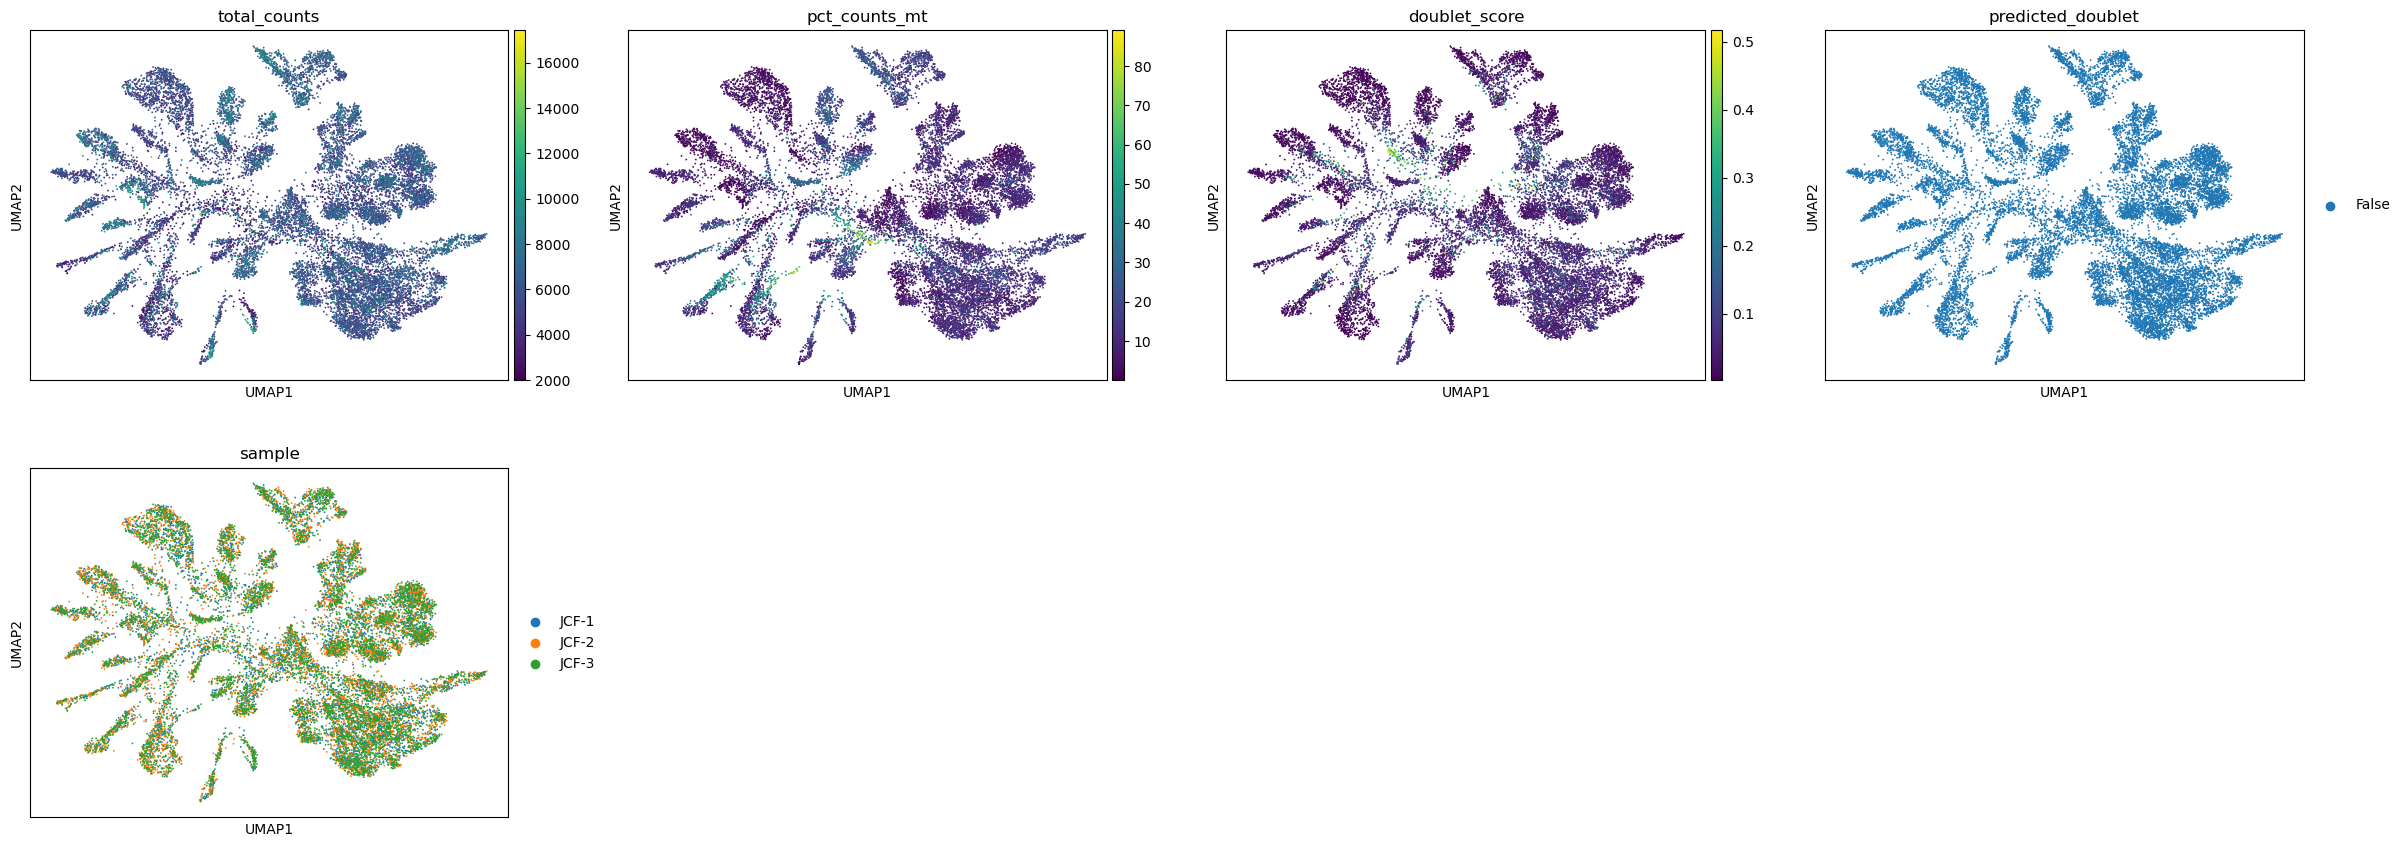

In [23]:
sc.pl.umap(
    adata,
    color=["total_counts", "pct_counts_mt", 'doublet_score', "predicted_doublet", 'sample'],
)

In [24]:
# Annotate the cluster at different resolutions
sc.tl.leiden(adata, key_added="leiden_res0_25", resolution=0.25)
sc.tl.leiden(adata, key_added="leiden_res0_5", resolution=0.5)
sc.tl.leiden(adata, key_added="leiden_res1", resolution=1.0)
sc.tl.leiden(adata, key_added="leiden_res3", resolution=3.0)

/scratch/qiw071/job_5539280/ipykernel_2789392/1811118288.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, key_added="leiden_res0_25", resolution=0.25)


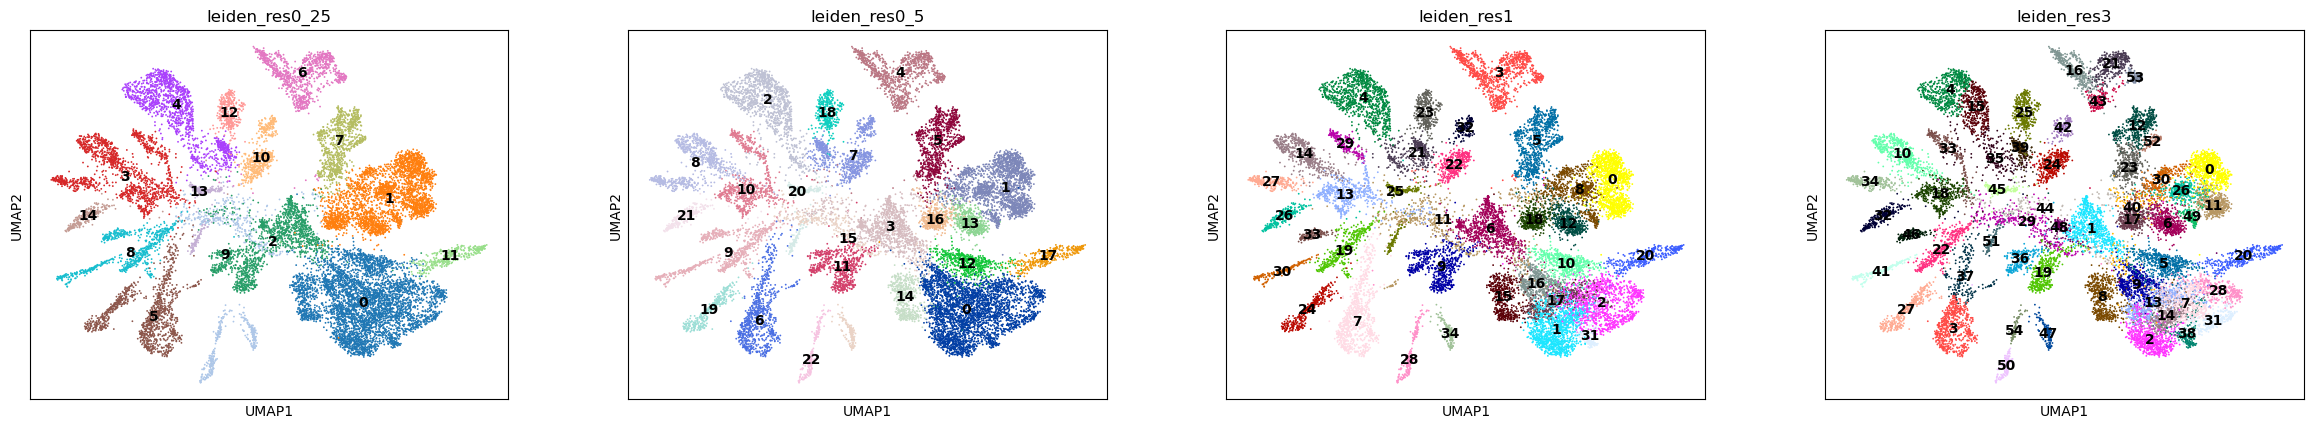

In [25]:
sc.pl.umap(
    adata,
    color=["leiden_res0_25", "leiden_res0_5", "leiden_res1", "leiden_res3"],
    legend_loc="on data",
)

In [26]:
# based on these leiden coloring resolution, pick one to use
leiden_to_use = "leiden_res1"

# Manual Annotation Based on Marker Genes

Now the cells are ready to be annotated. Take a look at the marker gene expression in each cluster to determine their identity.

## General Celltypes

In [2]:
# load marker gene list for general celltypes
df = pd.read_csv('../6-grammar_final/refs/curated_broad_tissue_marker_table.csv')

In [3]:
df.head()

,tissue marker,marker gene,ky,kh,Reference stage,in situ annotation on aniseed,notes,reference
0,Notochord (secondary),Ci-Noto4,KY21.Chr1.1467,KH.L18.30,Gastrula,notochord,looks like only labeling secondary notochord,Katikala et al. (2013)
1,Notochord,FBCD1; FGL1; FGL2,KY21.Chr1.290,KH.C1.832,Gastrula,notochord,NaN,"Hotta et al. (2000), Takahashi et al. (1999)"
2,Notochord,Noto8,KY21.Chr11.414,KH.C11.737,Gastrula,notochord,NaN,Katikala et al. (2013)
3,Notochord,TBX19; TBX6; TBXT,KY21.Chr12.6,KH.S1404.1,Gastrula,notochord,NaN,"Yasuo et al. (2007), Hotta et al. (2000)"
4,Notochord,Orphan bHLH1,KY21.Chr7.1130,KH.C7.269,Gastrula,notochord,NaN,"Satou et al. (2004), Imai et al. (2004)"


In [44]:
general_marker_dict = df[['tissue marker', 'marker gene']]\
                            .groupby('tissue marker').agg(list).to_dict()['marker gene']

In [45]:
celltype_order = [
    'Epidermis (b6.5)', 'Neural Plate (general)', 'Mesenchyme (TLC) + Neural Plate', 'Mesenchyme (TLC) + Endoderm (A)', 
    'Notochord ', 'Mesenchyme (TLC)  + Endoderm (general)','Endoderm (A)', 'Notochord (secondary) ', 'Mesenchyme', 'Epidermis (a)', 'Epidermis (general)', 
    'Heart', 'Heart/Muscle', 'Germ Cells'
                 ]

In [46]:
general_marker_dict = {k: general_marker_dict[k] for k in celltype_order if k in general_marker_dict}

categories: 0, 1, 2, etc.
var_group_labels: Epidermis (b6.5), Neural Plate (general), Mesenchyme (TLC) + Neural Plate, etc.


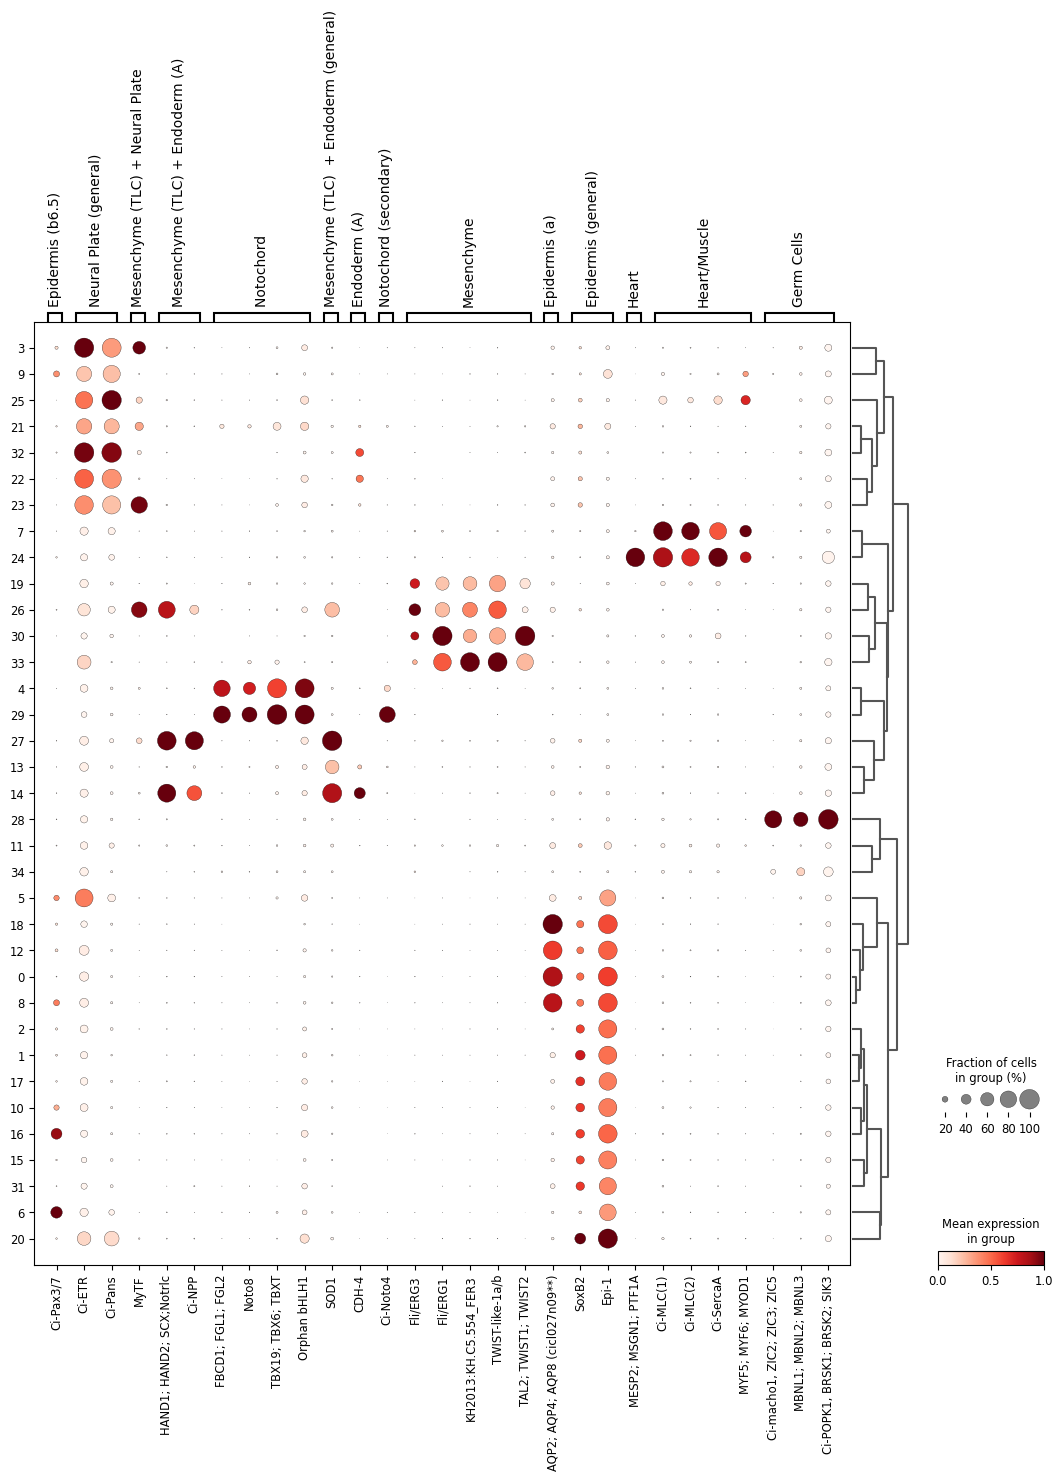

In [47]:
sc.tl.dendrogram(adata, groupby=leiden_to_use)
dotplot = sc.pl.dotplot(
    adata,
    groupby=leiden_to_use,
    var_names=general_marker_dict,
    gene_symbols ='Gene Name',
    return_fig = True,
    dendrogram = True,
    standard_scale="var", # colors are normalized by each gene
)
dotplot.show()

Based on the dotplot above, should be able to assign each cluster to their corresponding celltype ;)

In [33]:
my_celltype_map={
    '3':'Neural', '9':'Neural', '25':'Neural', '21':'Neural', '32':'Neural', '22':'Neural', '23':'Neural', '7':'Muscle', '24':'Heart',
    '19':'Mesenchyme', '26':'Trunk Lateral Cell', '30':'Mesenchyme', '33':'Mesenchyme', '4':'Primary Notochord', '29':'Secondary Notochord', 
    '27':'Endoderm (A)', '13':'Endoderm (B)', '14':'Endoderm (A)', '28':'Germ Cell', '11':'Unknown', '34':'Unknown', '5':'Neural', 
    '18':'Epidermis (a)', '12':'Epidermis (a)', '0':'Epidermis (a)', '8':'Epidermis (a)', '2':'Epidermis (b)', '1':'Epidermis (b)', '17':'Epidermis (b)', 
    '10':'Epidermis (b)', '16':'Epidermis (b)', '15':'Epidermis (b)', '31':'Epidermis (b)', '6':'b6.5-epi', '20':'Epidermis (b)'
}

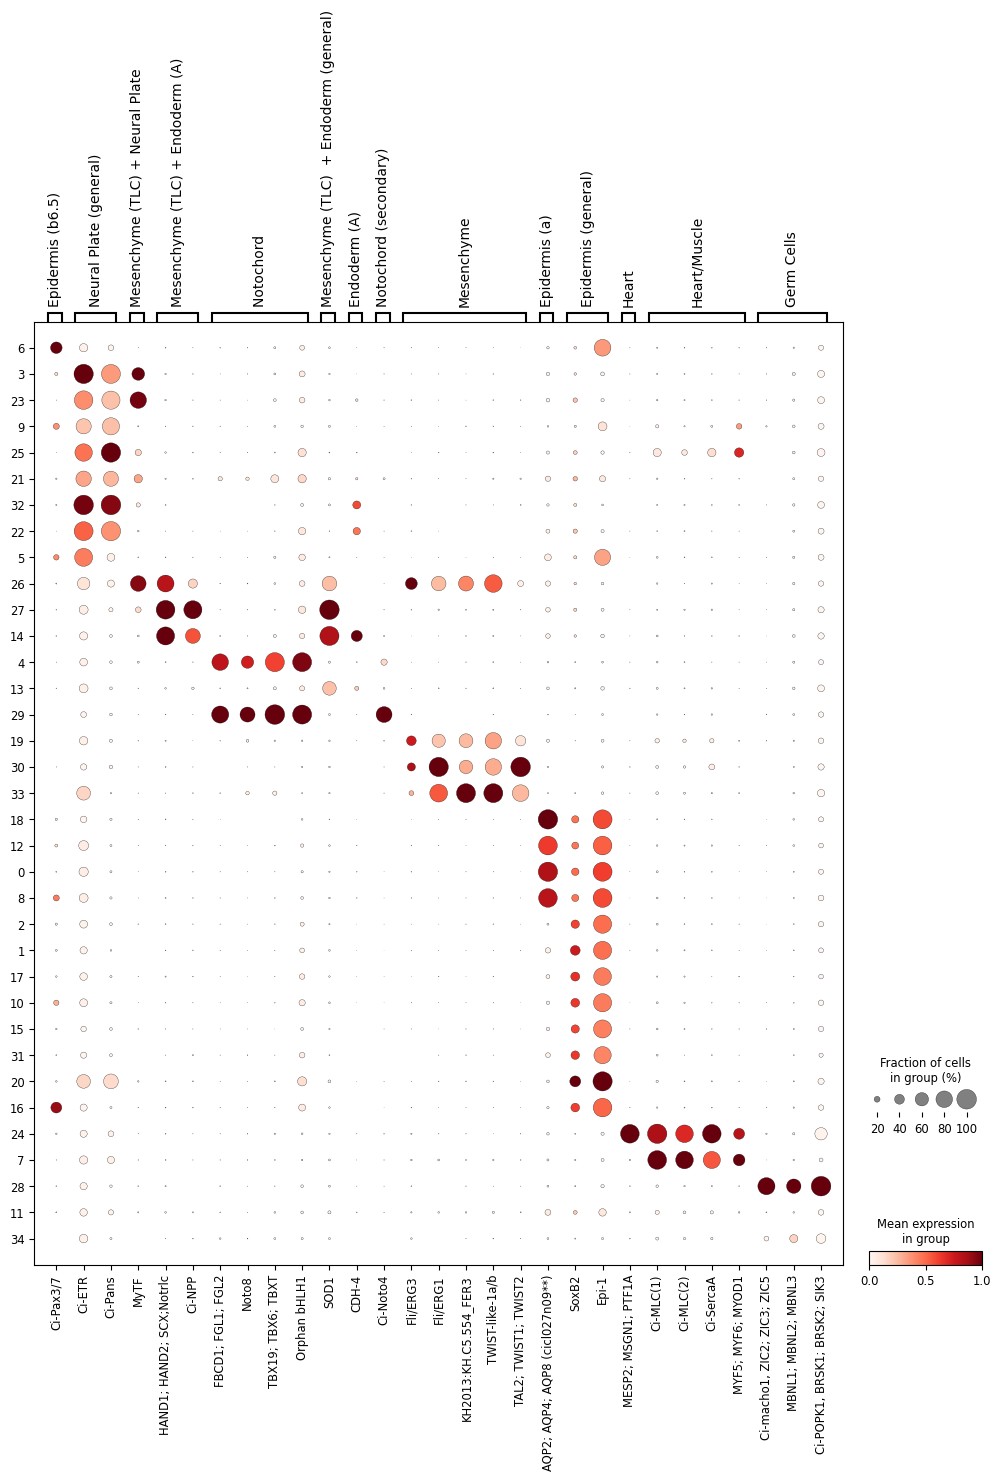

In [48]:
# reorder the clusters to preview before collapsing
dotplot = sc.pl.dotplot(
    adata,
    groupby=leiden_to_use,
    var_names=general_marker_dict,
    gene_symbols ='Gene Name',
    return_fig = True,
    dendrogram = False,
    standard_scale="var", # colors are normalized by each gene
    categories_order = ['6', '3', '23', '9', '25', '21', '32', '22', '5', '26', '27', '14', '4', '13', '29', '19', '30', '33', '18', '12', '0', '8', 
                        '2', '1', '17', '10', '15', '31', '20', '16', '24', '7', '28', '11', '34']
)
dotplot.show()

In [35]:
adata.obs['celltype'] = adata.obs[leiden_to_use].map(my_celltype_map)

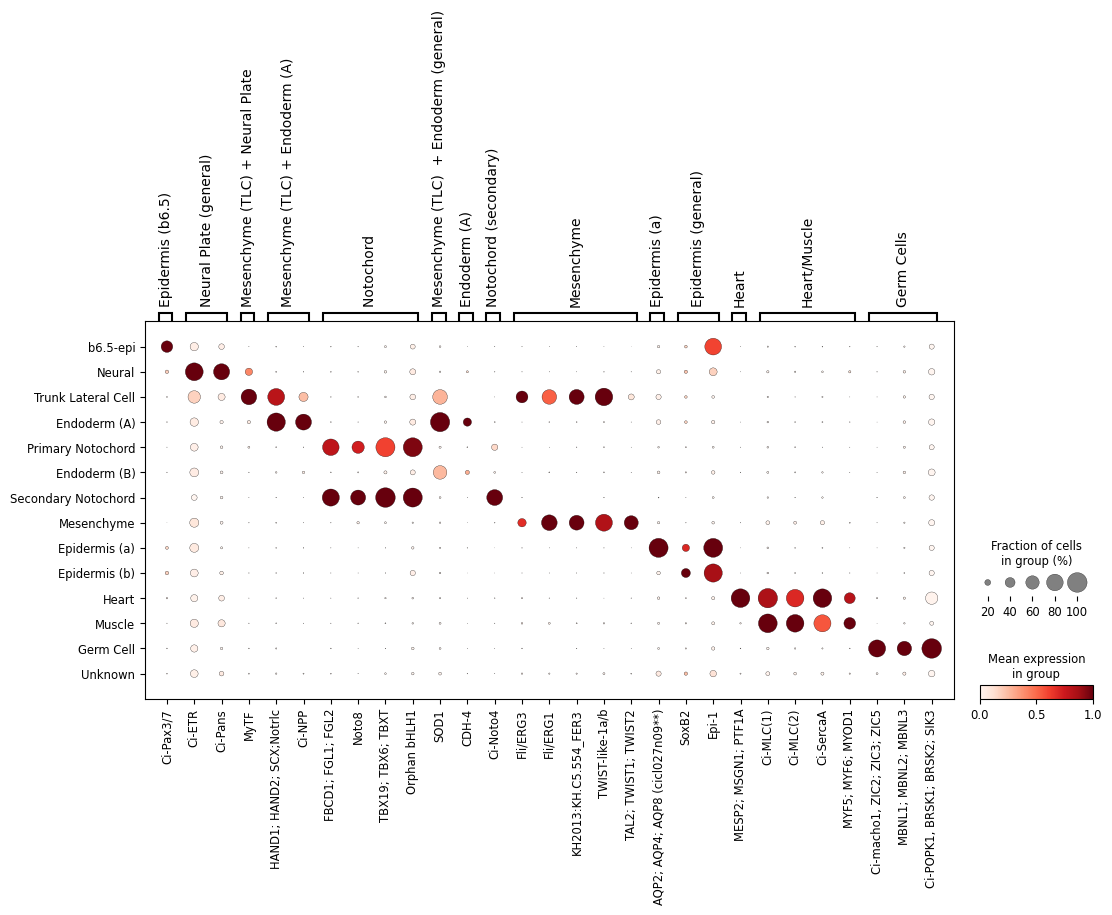

In [49]:
# collapse on annotated celltype and see the marker gene dotplot
dotplot = sc.pl.dotplot(
    adata,
    groupby='celltype',
    var_names=general_marker_dict,
    gene_symbols ='Gene Name',
    return_fig = True,
    dendrogram = False,
    standard_scale="var", # colors are normalized by each gene
    categories_order = ['b6.5-epi', 'Neural', 'Trunk Lateral Cell', 'Endoderm (A)', 'Primary Notochord', 'Endoderm (B)', 
                        'Secondary Notochord', 'Mesenchyme', 'Epidermis (a)', 'Epidermis (b)', 'Heart', 'Muscle', 'Germ Cell', 'Unknown']
)
dotplot.show()

## Neural Plate Celltypes

In [50]:
# extract the neural cells from the adata object
ndata = adata[adata.obs['celltype']=='Neural']

In [4]:
# load marker gene list for neural celltypes
df = pd.read_csv('../6-grammar_final/refs/curated_np_tissue_marker_table.csv')

In [5]:
df.head()

,tissue marker,layer,marker gene,ky,kh,Reference stage,in situ annotation on aniseed,notes,reference
0,b6.5-neural_muscle,General,Msx,KY21.Chr2.1031,KH2012:KH.C2.957,Gastrula,a9.49 cell pair - b9.37 cell pair - b9.38 cell...,NaN,Esposito et al. (2017)
1,b6.5-neural_muscle,General,FAM167A; FAM167B,KY21.Chr2.907,KH2012:KH.C2.629,Gastrula,b9.33\tb9.34 pair,NaN,Winkley et al. (2021)
2,b6.5-neural_muscle,General,LHX1; LMX1A; LMX1B,KY21.Chr9.606,KH2012:KH.C9.616,Gastrula,b9.37 cell pair - b9.38 cell pair,NaN,Imai et al. (2009)
3,a,General,DMRT1; DMRTA1; DMRTA2,KY21.Chr5.707,KH2012:KH.S544.3,Gastrula,a line neural plate,NaN,Wagner et al. (2012)
4,a,General,MUSK; ROR1; ROR2,KY21.Chr8.665,KH2012:KH.C8.101,Gastrula,row III neural plate - row IV neural plate - r...,NaN,Lamy et al. (2006)


In [52]:
neural_marker_dict = df[df['layer']=='General'][['tissue marker', 'marker gene']]\
                            .groupby('tissue marker').agg(list).to_dict()['marker gene']

In [53]:
A_marker_dict = df[df['layer']=='A'][['tissue marker', 'marker gene']]\
                            .groupby('tissue marker').agg(list).to_dict()['marker gene']

In [54]:
a_marker_dict = df[df['layer']=='a'][['tissue marker', 'marker gene']]\
                            .groupby('tissue marker').agg(list).to_dict()['marker gene']

In [55]:
b_marker_dict = df[df['layer']=='b'][['tissue marker', 'marker gene']]\
                            .groupby('tissue marker').agg(list).to_dict()['marker gene']

In [56]:
neural_marker_dict

{'A': ['Mnx', 'ZEB1; ZEB2; ZNF22'],
 'a': ['DMRT1; DMRTA1; DMRTA2', 'MUSK; ROR1; ROR2', 'sFRP1/5'],
 'b6.5-neural_muscle': ['Msx', 'FAM167A; FAM167B', 'LHX1; LMX1A; LMX1B']}

/tscc/nfs/home/qiw071/ENTER/envs/single_cell/lib/python3.12/site-packages/scanpy/tools/_dendrogram.py:193: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = dat


categories: 3, 5, 9, etc.
var_group_labels: A, a, b6.5-neural_muscle


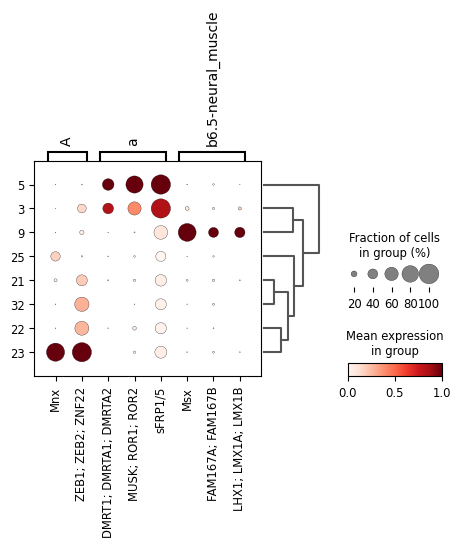

In [57]:
sc.tl.dendrogram(ndata, groupby=leiden_to_use)
dotplot = sc.pl.dotplot(
    ndata,
    groupby=leiden_to_use,
    var_names=neural_marker_dict,
    gene_symbols ='Gene Name',
    return_fig = True,
    dendrogram = True,
    standard_scale="var", # colors are normalized by each gene
)
dotplot.show()

In [58]:
# based on the above dotplot, assign the corresponding celltypes
my_celltype_map={
    '5':'a', '3':'a',
    '9':'b6.5-neural_muscle',
    '25':'A', '21':'A', '32':'A', '22':'A', '23':'A'
}

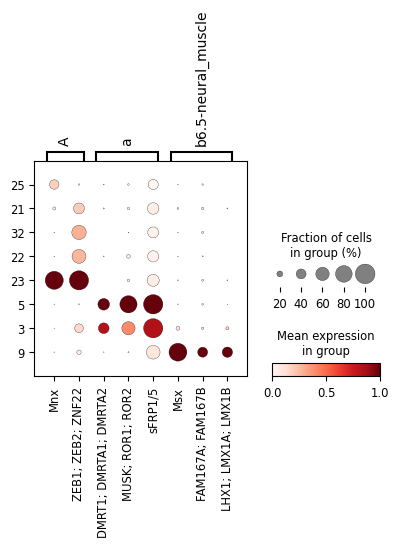

In [59]:
# Preview on how it's gonna be grouped
dotplot = sc.pl.dotplot(
    ndata,
    groupby=leiden_to_use,
    categories_order = ['25', '21', '32', '22', '23', '5', '3', '9'],
    var_names=neural_marker_dict,
    gene_symbols ='Gene Name',
    return_fig = True,
    dendrogram = False,
    standard_scale="var", # colors are normalized by each gene
)
dotplot.show()

In [60]:
ndata.obs['celltype']=ndata.obs[leiden_to_use].map(my_celltype_map)

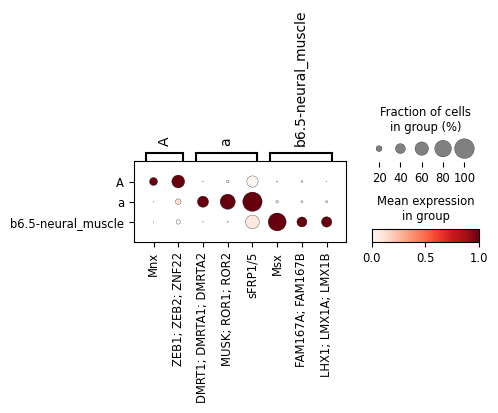

In [61]:
dotplot = sc.pl.dotplot(
    ndata,
    groupby='celltype',
    var_names=neural_marker_dict,
    gene_symbols ='Gene Name',
    return_fig = True,
    dendrogram = False,
    standard_scale="var", # colors are normalized by each gene
)
dotplot.show()

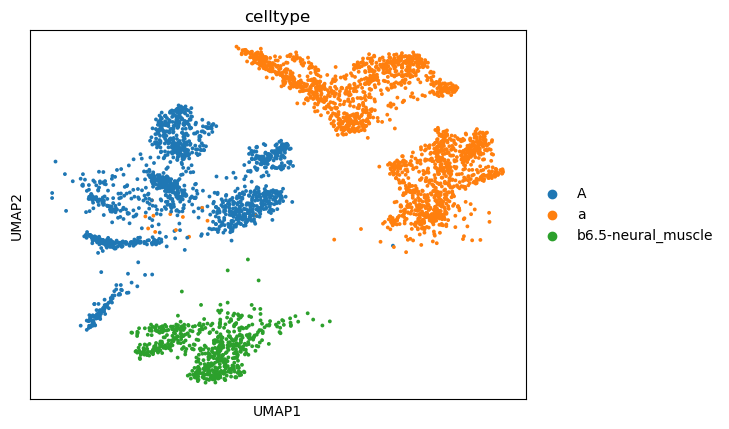

In [62]:
sc.pl.umap(ndata, color=['celltype'])

## A-line Celltypes

In [63]:
Adata = ndata[ndata.obs['celltype']=='A']

In [64]:
A_marker_dict

{'A9.13, A9.15, A9.14, A9.16': ['ZEB1; ZEB2; ZNF22'],
 'LNC': ['EFNA1; EFNA4; EFNA5', 'EFNA1; EFNA5; EFNB2', 'DLK2; DLL1'],
 'Muscle': ['Ci-MLC(1)', 'Ci-MLC(2)', 'Ci-SercaA', 'MYF5; MYF6; MYOD1'],
 'NP Row 2 (A9.14, A9.16, A9.30, A9.32)': ['FGF16; FGF20; FGF9'],
 'VNC (A9.13, A9.15)': ['Mnx']}

/tscc/nfs/home/qiw071/ENTER/envs/single_cell/lib/python3.12/site-packages/scanpy/tools/_leiden.py:197: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_added] = pd.Categorical(


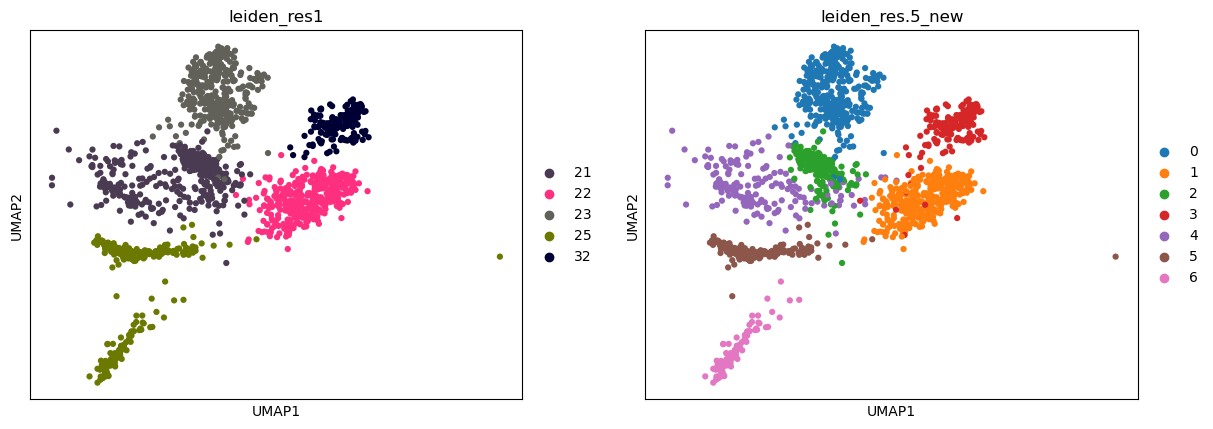

In [65]:
# subcluster it to get finner resolution
# now we start to use the UMAP on th right
sc.tl.leiden(Adata, key_added="leiden_res.5_new", resolution=0.5)
sc.pl.umap(Adata, color=[leiden_to_use, "leiden_res.5_new"])

In [66]:
leiden_to_use="leiden_res.5_new"

categories: 0, 1, 2, etc.
var_group_labels: A9.13, A9.15, A9.14, A9.16, LNC, Muscle, etc.


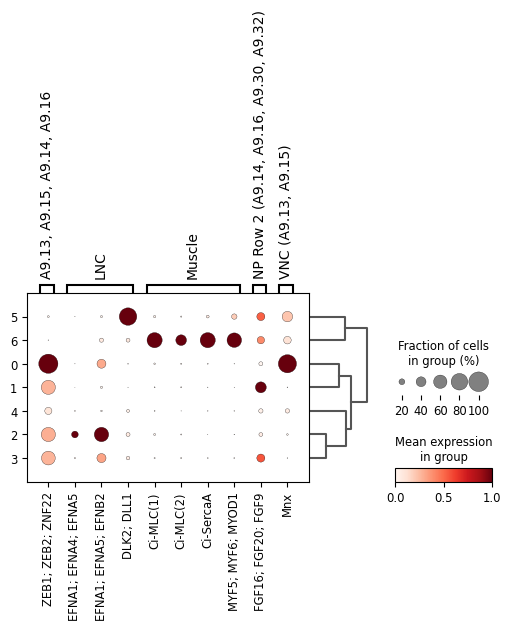

In [67]:
sc.tl.dendrogram(Adata, groupby=leiden_to_use)
dotplot = sc.pl.dotplot(
    Adata,
    groupby=leiden_to_use,
    var_names=A_marker_dict,
    gene_symbols ='Gene Name',
    return_fig = True,
    dendrogram = True,
    standard_scale="var", # colors are normalized by each gene
)
dotplot.show()

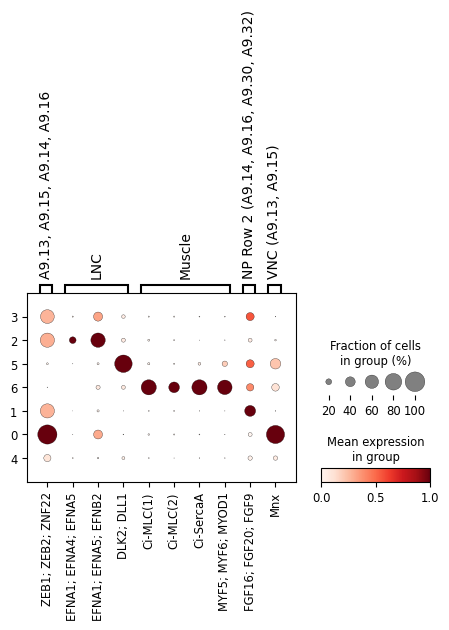

In [68]:
# preview on how it's gonna be grouped
dotplot = sc.pl.dotplot(
    Adata,
    groupby=leiden_to_use,
    var_names=A_marker_dict,
    gene_symbols ='Gene Name',
    return_fig = True,
    dendrogram = False,
    categories_order = ['3', '2', '5', '6', '1', '0', '4'],
    standard_scale="var", # colors are normalized by each gene
)
dotplot.show()

In [69]:
# based on the above dotplot, assign the corresponding celltypes
my_celltype_map={
    '5':'LNC', '1':'ASV/PSV (A9.14, A9.16)', '0':'VNC + PSV (A9.13, A9.15)', '4':'Unknown', 
    '2':'LNC', '3':'LNC', '6':'Muscle (A)'
}

In [70]:
Adata.obs['celltype']=Adata.obs[leiden_to_use].map(my_celltype_map)

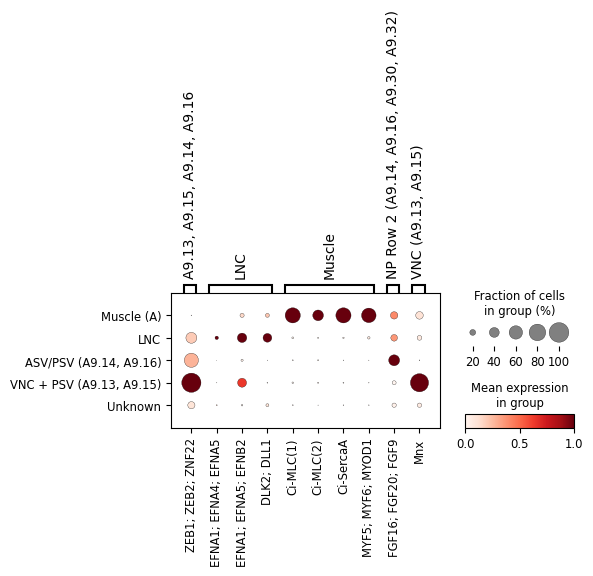

In [72]:
dotplot = sc.pl.dotplot(
    Adata,
    groupby='celltype',
    var_names=A_marker_dict,
    gene_symbols ='Gene Name',
    return_fig = True,
    dendrogram = False,
    standard_scale="var", # colors are normalized by each gene
    categories_order =['Muscle (A)','LNC','ASV/PSV (A9.14, A9.16)', 'VNC + PSV (A9.13, A9.15)', 'Unknown' ],
)
dotplot.show()

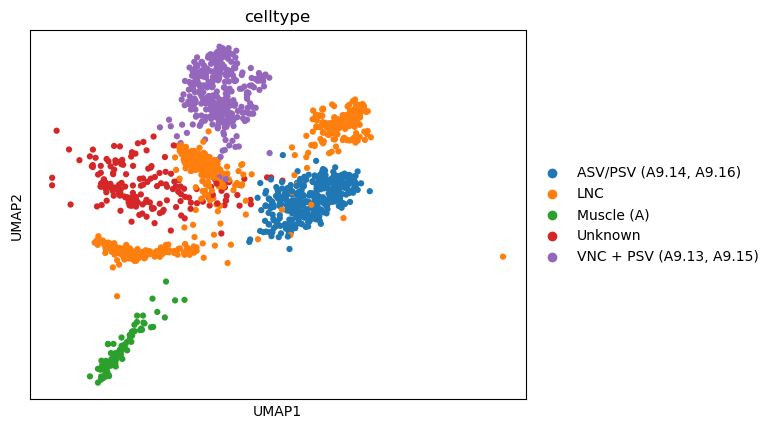

In [73]:
sc.pl.umap(Adata, color=['celltype'])

## a-line Celltypes

In [74]:
aadata = ndata[ndata.obs['celltype']=='a']

/tscc/nfs/home/qiw071/ENTER/envs/single_cell/lib/python3.12/site-packages/scanpy/tools/_leiden.py:197: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_added] = pd.Categorical(


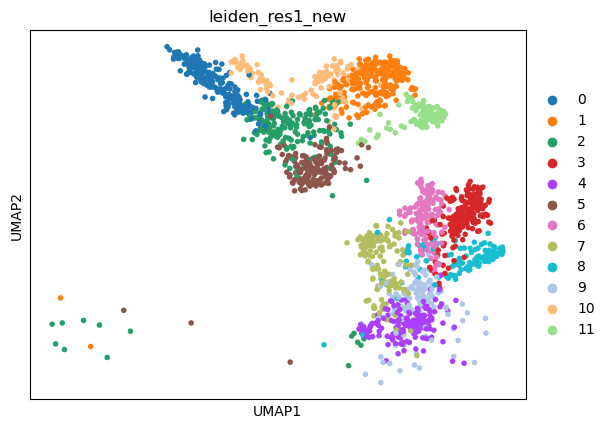

In [75]:
# under the similar logic: subcluster it to get finner resolution
sc.tl.leiden(aadata, key_added="leiden_res1_new", resolution=1)
sc.pl.umap(aadata, color=["leiden_res1_new"])

In [77]:
leiden_to_use = "leiden_res1_new"

In [78]:
a_marker_dict

{'a6.5 (NP Row 3-4)': ['MyTF'],
 'a6.5 (NP Row 3-4) + a9.49 + a9.50': ['NPBWR1; RGR; RRH'],
 'a6.5 (NP Row 4) + a9.50': ['SIX1; SIX3; SIX6'],
 'a6.5 (NP Row 5-6)': ['FOXC1; FOXC2; FOXL1'],
 'a9.49': ['TYRO; TYRP1; TYRP2 (Tyrp1a**)'],
 'a9.49 + a9.50': ['Ci-Pax3/7', 'DLK2; DLL1', 'SNAI1; SNAI2; SNAI3']}

categories: 0, 1, 2, etc.
var_group_labels: a6.5 (NP Row 3-4), a6.5 (NP Row 3-4) + a9.49 + a9.50, a6.5 (NP Row 4) + a9.50, etc.


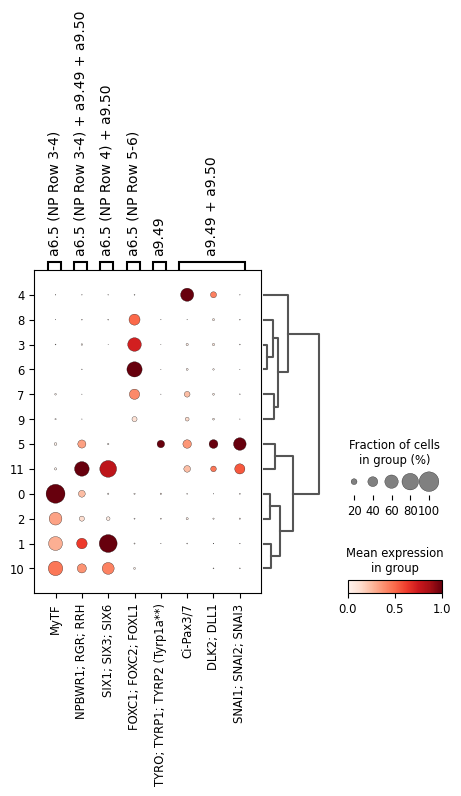

In [79]:
sc.tl.dendrogram(aadata, groupby=leiden_to_use)
dotplot = sc.pl.dotplot(
    aadata,
    groupby=leiden_to_use,
    var_names=a_marker_dict,
    gene_symbols ='Gene Name',
    return_fig = True,
    dendrogram = True,
    standard_scale="var", # colors are normalized by each gene
)
dotplot.show()

In [80]:
my_celltype_map={
    '4':'ASV (a9.50)', 
    '7':'a6.5 (NP Row 5-6)', '6':'a6.5 (NP Row 5-6)', '3':'a6.5 (NP Row 5-6)', '8':'a6.5 (NP Row 5-6)', '9':'ASV (a9.51, a9.52)',
    '0':'a6.5 (NP Row 3-4)', '2':'a6.5 (NP Row 3-4)', '1':'a6.5 (NP Row 3-4)', '10':'a6.5 (NP Row 3-4)',
    '5':'PSV (a9.49)', '11':'ASV (a9.50)'
}

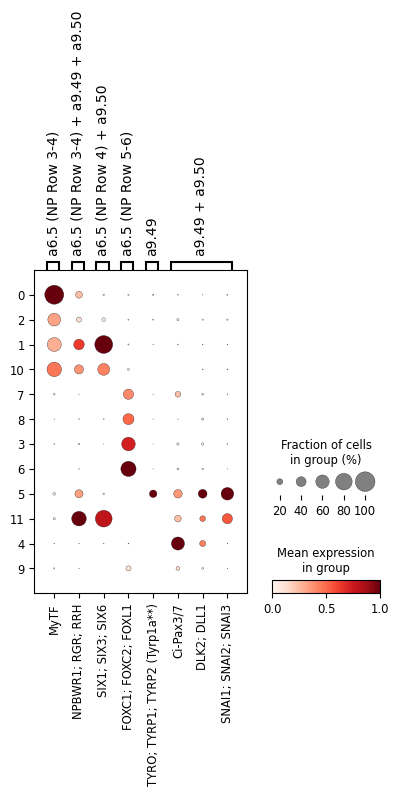

In [81]:
# preview on how it's gonna be collapsed
dotplot = sc.pl.dotplot(
    aadata,
    groupby=leiden_to_use,
    var_names=a_marker_dict,
    gene_symbols ='Gene Name',
    return_fig = True,
    dendrogram = False,
    standard_scale="var", # colors are normalized by each gene
    categories_order = ['0', '2', '1', '10', '7', '8', '3', '6', '5', '11', '4', '9']
)
dotplot.show()

In [82]:
aadata.obs['celltype']=aadata.obs[leiden_to_use].map(my_celltype_map)

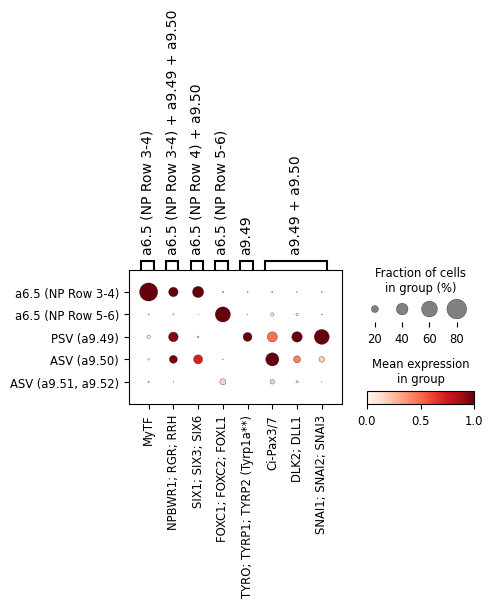

In [83]:
dotplot = sc.pl.dotplot(
    aadata,
    groupby='celltype',
    var_names=a_marker_dict,
    gene_symbols ='Gene Name',
    return_fig = True,
    dendrogram = False,
    standard_scale="var", # colors are normalized by each gene
    categories_order = ['a6.5 (NP Row 3-4)', 'a6.5 (NP Row 5-6)', 'PSV (a9.49)', 'ASV (a9.50)', 'ASV (a9.51, a9.52)'],
)
dotplot.show()

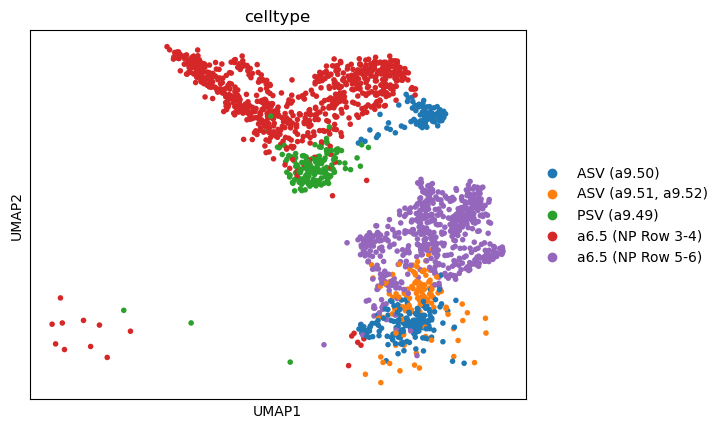

In [84]:
sc.pl.umap(aadata, color=['celltype'])

In [85]:
# update the previous celltype lable
aadata.obs['celltype']=aadata.obs[leiden_to_use].map(my_celltype_map).fillna(aadata.obs['celltype'])

## b-line celltypes

In [86]:
bdata = ndata[ndata.obs['celltype']=='b6.5-neural_muscle']

/tscc/nfs/home/qiw071/ENTER/envs/single_cell/lib/python3.12/site-packages/scanpy/tools/_leiden.py:197: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_added] = pd.Categorical(


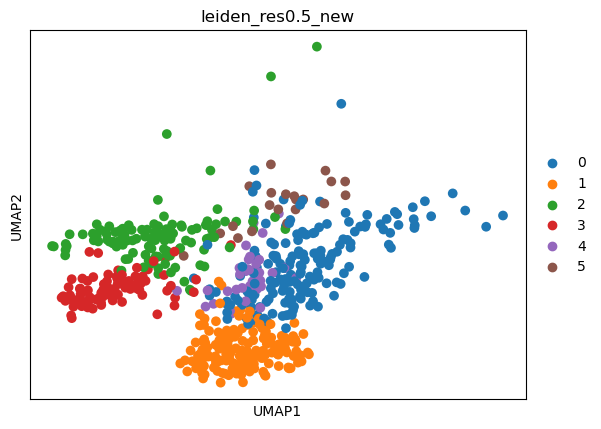

In [87]:
# under the similar logic: subcluster it to get finner resolution
sc.tl.leiden(bdata, key_added="leiden_res0.5_new", resolution=0.5)
sc.pl.umap(bdata, color=["leiden_res0.5_new"])

In [88]:
leiden_to_use = "leiden_res0.5_new"

categories: 0, 1, 2, etc.
var_group_labels: Muscle


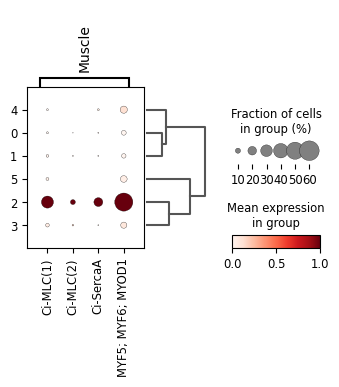

In [89]:
sc.tl.dendrogram(bdata, groupby=leiden_to_use)
dotplot = sc.pl.dotplot(
    bdata,
    groupby=leiden_to_use,
    var_names=b_marker_dict,
    gene_symbols ='Gene Name',
    return_fig = True,
    dendrogram = True,
    standard_scale="var", # colors are normalized by each gene
)
dotplot.show()

In [90]:
my_celltype_map={
    '2':'b6.5-muscle', '0':'b6.5-neural', '1':'b6.5-neural', '3':'b6.5-neural', '4':'b6.5-neural', '5':'b6.5-neural', 
}

In [91]:
# update the previous celltype lable
bdata.obs['celltype']=bdata.obs[leiden_to_use].map(my_celltype_map)

## Aggregate celltype annotations back to adata

In [92]:
detailed_celltype = pd.concat([Adata.obs[['celltype']], bdata.obs[['celltype']], aadata.obs[['celltype']]])

In [93]:
temp = ndata.obs[['celltype']].merge(detailed_celltype, left_index=True, right_index=True, how = 'left')

In [94]:
temp

,celltype_x,celltype_y
AAACCATTCGATCATG-1,a,a6.5 (NP Row 5-6)
AAACGAATCAGGAGTG-1,a,a6.5 (NP Row 5-6)
AAAGCTGGTGAAGCAC-1,A,Unknown
AAATGAGTCGCTCGCT-1,a,a6.5 (NP Row 5-6)
AAATGGGCAATCGACG-1,A,LNC
...,...,...
TGTCCAGGTTCCGGGT-1,b6.5-neural_muscle,b6.5-neural
TGTCCCTGTGATAGGC-1,b6.5-neural_muscle,b6.5-neural
TGTCCCTGTTTCGGGC-1,a,a6.5 (NP Row 3-4)
TGTCTGTTCCCCAAGG-1,a,a6.5 (NP Row 3-4)


In [95]:
temp['celltype_n'] = temp['celltype_y'].combine_first(temp['celltype_x'])

In [96]:
adata.obs = adata.obs.merge(temp['celltype_n'],left_index = True, right_index = True, how = 'left')

In [97]:
adata.obs['updated_label'] = adata.obs['celltype_n'].combine_first(adata.obs['celltype'])

In [98]:
adata.obs.drop(columns = 'celltype_n', inplace = True)

In [99]:
# Now, everything we need is in the updated label column
adata.obs

,sample,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,n_genes,n_counts,doublet_score,predicted_doublet,leiden_res0_25,leiden_res0_5,leiden_res1,leiden_res3,celltype,updated_label
AAACCAAAGGAATTAG-1,JCF-1,2998,6414.0,589.0,9.183037,2998,6414.0,0.028930,False,1,1,0,11,Epidermis (a),Epidermis (a)
AAACCAAAGTTAGACT-1,JCF-1,2544,10464.0,6727.0,64.287079,2544,10464.0,0.020458,False,9,15,34,47,Unknown,Unknown
AAACCATTCGATCATG-1,JCF-1,2895,5548.0,586.0,10.562365,2895,5548.0,0.031000,False,7,5,5,52,Neural,a6.5 (NP Row 5-6)
AAACCCGCAAGTTAGC-1,JCF-1,2883,5438.0,405.0,7.447591,2883,5438.0,0.034410,False,3,8,14,10,Endoderm (A),Endoderm (A)
AAACCCGCAATCGAGT-1,JCF-1,3198,6931.0,866.0,12.494590,3197,6931.0,0.029946,False,0,14,15,8,Epidermis (b),Epidermis (b)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTGTACGTGCGGTTC-1,JCF-3,2633,4605.0,185.0,4.017373,2632,4605.0,0.025244,False,14,21,26,32,Trunk Lateral Cell,Trunk Lateral Cell
TGTGTACGTTAATCGC-1,JCF-3,2220,3575.0,31.0,0.867133,2220,3575.0,0.009351,False,7,5,5,12,Neural,a6.5 (NP Row 5-6)
TGTGTTGAGGTACGGA-1,JCF-3,2192,3492.0,62.0,1.775487,2192,3492.0,0.009737,False,4,2,4,15,Primary Notochord,Primary Notochord
TGTGTTGAGGTCGAAG-1,JCF-3,2547,4596.0,180.0,3.916449,2547,4596.0,0.232323,False,3,10,13,18,Endoderm (B),Endoderm (B)


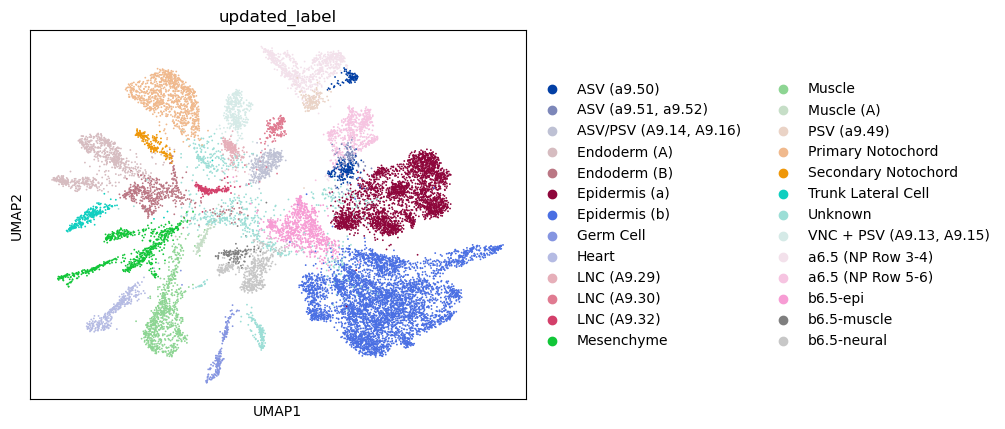

In [5]:
sc.pl.umap(adata, color=['updated_label'])

In [101]:
# for the purpose of the enhancer expression analysis, aggregate some celltypes
collapse_celltype = { 
                     'VNC + PSV (A9.13, A9.15)':'VNC + PSV', 
                     'ASV/PSV (A9.14, A9.16)':'A-line ASV/PSV', 
                     'a6.5 (NP Row 3-4)':'a6.5', 'a6.5 (NP Row 5-6)':'a6.5', 'b6.5-epi':'b6.5', 
                     'b6.5-neural':'b6.5','b6.5-muscle':'b6.5', 'PSV (a9.49)':'a6.7 PSV', 'ASV (a9.50)':'a6.7 ASV', 'ASV (a9.51, a9.52)':'a6.7 ASV', 
                     'Muscle (A)':'Muscle A/B', 'Muscle':'Muscle A/B'
                    }

In [102]:
adata.obs['col_celltype'] = adata.obs['updated_label'].map(collapse_celltype).fillna(adata.obs['updated_label'])

In [7]:
adata = sc.read('../6-grammar_final/JCF-HT_annotated.h5ad')

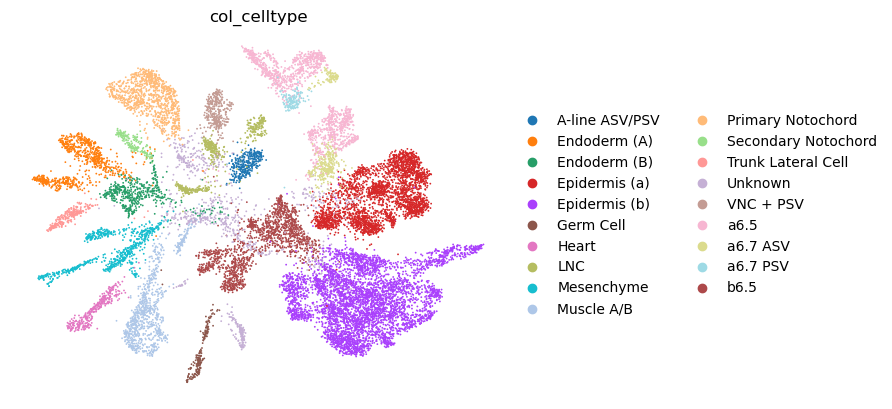

In [34]:
# Final UMAP
umap_plot = sc.pl.umap(adata, color=['col_celltype'],frameon=False,return_fig = True)

In [42]:
umap_plot.savefig('../6-grammar_final/figs/fig27a_umap.png', format="png", dpi = 600, bbox_inches="tight")

In [10]:
final_markers = {
    'b6.5-neural_muscle': ['Msx', 'FAM167A; FAM167B', 'LHX1; LMX1A; LMX1B'],
    'Epidermis (b6.5)+ a6.7': ['Ci-Pax3/7'],
    
    'neural-a': ['DMRT1; DMRTA1; DMRTA2', 'MUSK; ROR1; ROR2', 'sFRP1/5'],
    'a6.5 (NP Row 3-4) + a9.49 + a9.50': ['NPBWR1; RGR; RRH'],
    'a6.5 (NP Row 4) + a9.50': ['SIX1; SIX3; SIX6'],
    'a6.5 (NP Row 5-6)': ['FOXC1; FOXC2; FOXL1'],
    'a9.49 + a9.50 + LNC (A)' : ['DLK2; DLL1'],
    'a9.49 + a9.50': ['SNAI1; SNAI2; SNAI3'],
    'a9.49': ['TYRO; TYRP1; TYRP2 (Tyrp1a**)'],
    'Mesenchyme TLC (A) + neural-a': ['MyTF'],
    'Mesenchyme TLC (A) + Endoderm (A)': ['HAND1; HAND2; SCX;Notrlc', 'Ci-NPP'],
    'Endoderm (A)': ['CDH-4'],
    
    'Notochord (A+B)': ['FBCD1; FGL1; FGL2','Noto8','TBX19; TBX6; TBXT','Orphan bHLH1'],

    'A9.13, A9.15, A9.14, A9.16': ['ZEB1; ZEB2; ZNF22'],
    'VNC (A9.13, A9.15)': ['Mnx'],
    'NP Row 2 (A9.14, A9.16, A9.30, A9.32)': ['FGF16; FGF20; FGF9'],
    'LNC (A)': ['EFNA1; EFNA4; EFNA5', 'EFNA1; EFNA5; EFNB2'],

    'Endoderm (A+B)': ['SOD1'],
    'Notochord (B) ': ['Ci-Noto4', 'TGFBeta2'],
    'Mesenchyme (B)': ['Fli/ERG3','Fli/ERG1','KH2013:KH.C5.554_FER3','TWIST-like-1a/b','TAL2; TWIST1; TWIST2'],
    'Epidermis (a)': ['AQP2; AQP4; AQP8 (cicl027n09**)'],
    'Epidermis (a+b)': ['SoxB2', 'Epi-1'],
    'Heart (B)': ['MESP2; MSGN1; PTF1A'],
    'Heart/Muscle (A+B)': ['Ci-MLC(1)', 'Ci-MLC(2)', 'Ci-SercaA', 'MYF5; MYF6; MYOD1'],
    'Germ Cells (B)': ['Ci-macho1, ZIC2; ZIC3; ZIC5','MBNL1; MBNL2; MBNL3','Ci-POPK1, BRSK1; BRSK2; SIK3'],
}

In [12]:
# Final visualization
dotplot = sc.pl.dotplot(
    adata,    
    categories_order = ['b6.5','a6.5', 'a6.7 PSV','a6.7 ASV','Trunk Lateral Cell', 'Endoderm (A)','Primary Notochord',
                        'VNC + PSV','A-line ASV/PSV','LNC', 'Endoderm (B)','Secondary Notochord','Mesenchyme',
                        'Epidermis (a)','Epidermis (b)', 'Heart', 'Muscle A/B', 'Germ Cell', 'Unknown'],
    groupby='col_celltype',
    var_names=final_markers,
    gene_symbols ='Gene Name',
    return_fig = True,
    dendrogram = False,
    standard_scale="var", # colors are normalized by each gene
)

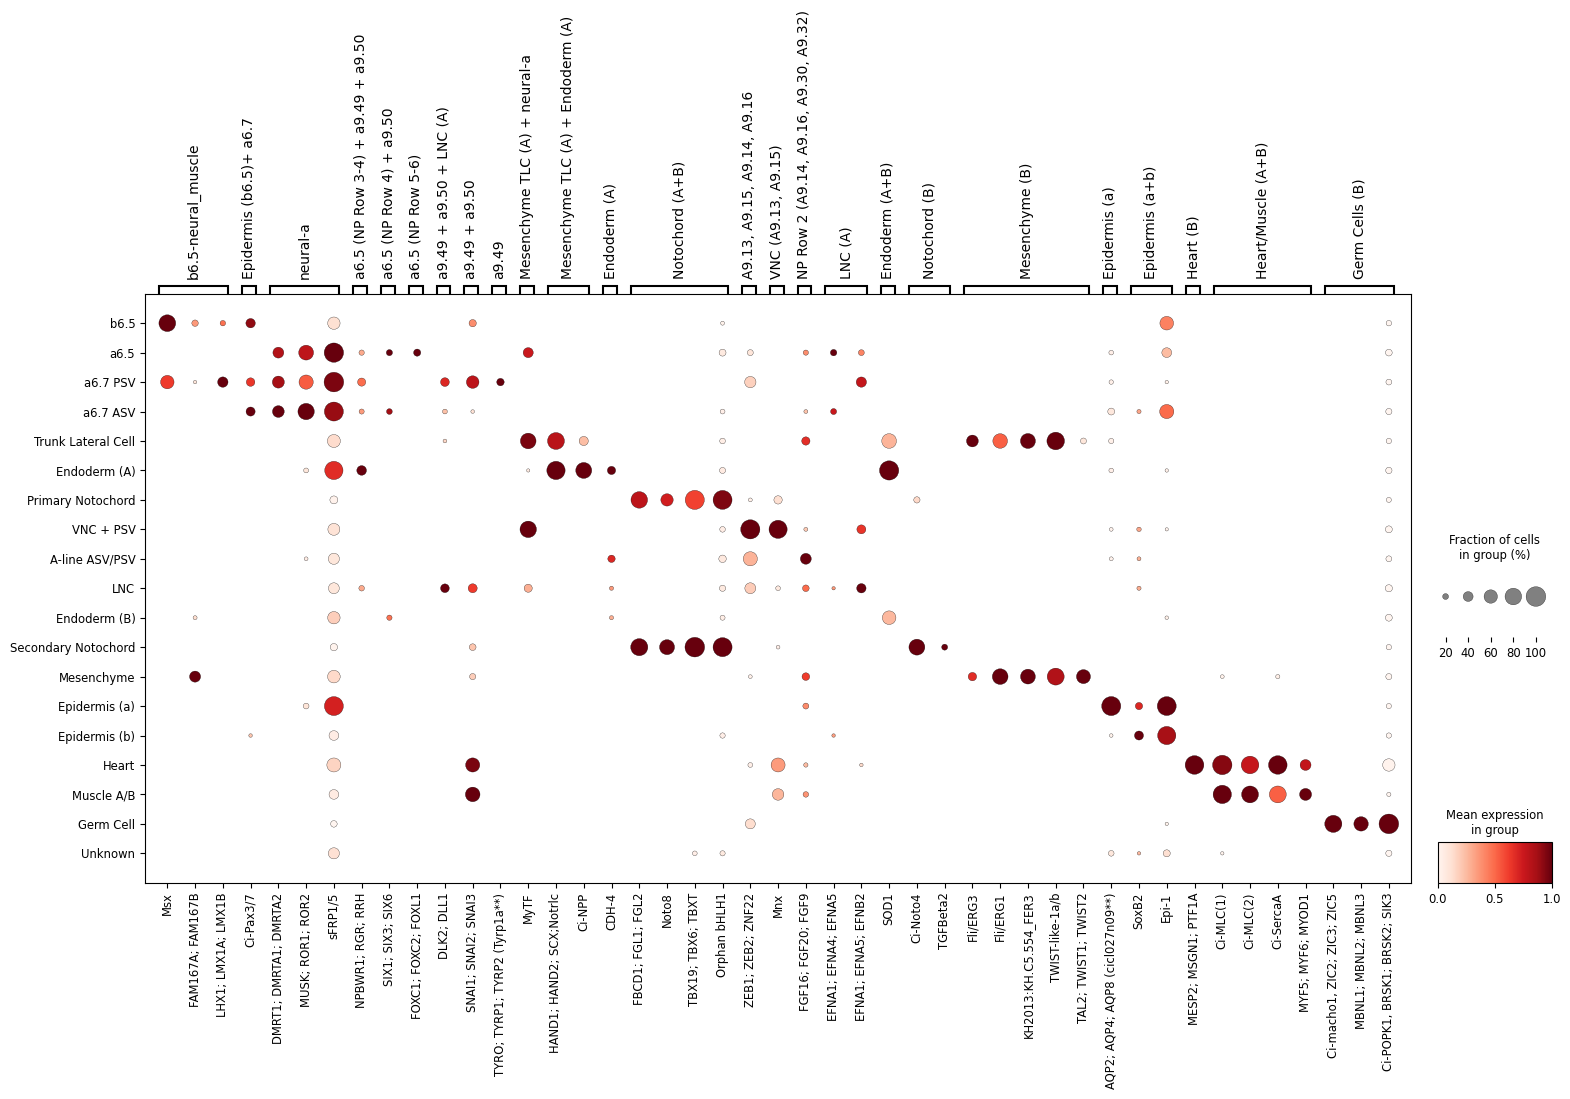

In [14]:
dot_min = 0.09
dotplot.dot_size_df = dotplot.dot_size_df.where(dotplot.dot_size_df>dot_min, 0)
#dotplot.show()
dotplot.savefig('../6-grammar_final/figs/fig27b_celltype_assignment_dotplot.svg', format="svg")

In [107]:
adata.obs['cellBC']=adata.obs.index.str.split('-').str[0]

# Quality Control: correlate with expected percentage

In [15]:
pct = pd.read_csv('../6-grammar_final/refs/cell_pct.csv', index_col = 0)

In [16]:
adata.obs['updated_label'].unique().tolist()

['Epidermis (a)',
 'Unknown',
 'a6.5 (NP Row 5-6)',
 'Endoderm (A)',
 'Epidermis (b)',
 'Muscle',
 'Primary Notochord',
 'Trunk Lateral Cell',
 'Endoderm (B)',
 'Mesenchyme',
 'b6.5-epi',
 'LNC (A9.32)',
 'a6.5 (NP Row 3-4)',
 'b6.5-neural',
 'Germ Cell',
 'LNC (A9.30)',
 'VNC + PSV (A9.13, A9.15)',
 'LNC (A9.29)',
 'ASV/PSV (A9.14, A9.16)',
 'Heart',
 'ASV (a9.51, a9.52)',
 'ASV (a9.50)',
 'Muscle (A)',
 'Secondary Notochord',
 'b6.5-muscle',
 'PSV (a9.49)']

In [25]:
celltype_pct_map = {
    'Epidermis (b)':'Epidermis', 'Epidermis (a)':'Epidermis', 'b6.5-epi':'Epidermis',
    'Primary Notochord':'Notochord', 'a6.5 (NP Row 3-4)':'a-neural', 'Endoderm (A)':'Endoderm', 'b6.5-neural':'b-neural','b6.5-muscle':'Muscle',
    'a6.5 (NP Row 5-6)':'a-neural', 'Endoderm (B)':'Endoderm', 'ASV/PSV (A9.14, A9.16)':'A-neural', 'VNC + PSV (A9.13, A9.15)':'A-neural',
    'Trunk Lateral Cell':'Mesenchyme', 'ASV (a9.50)':'a-neural', 'LNC (A9.29)':'A-neural', 'LNC (A9.30)':'A-neural',
    'ASV (a9.51, a9.52)':'A-neural', 'PSV (a9.49)':'a-neural', 'LNC (A9.32)':'A-neural','Secondary Notochord':'Notochord', 'Muscle (A)':'Muscle', 'Muscle (B)':'Muscle'
}

In [26]:
celltype_pct = adata.obs['updated_label'].map(celltype_pct_map).fillna(adata.obs['updated_label'])

In [27]:
celltype_pct[celltype_pct!='Unknown'].value_counts(normalize = True)*100

updated_label
Epidermis     50.138815
a-neural      10.366826
A-neural       7.809085
Endoderm       7.377872
Notochord      6.934846
Muscle         5.800697
Mesenchyme     5.528974
b-neural       2.929884
Heart          1.937504
Germ Cell      1.175498
Name: proportion, dtype: float64

In [28]:
pct['Observed_pct'] = celltype_pct[celltype_pct!='Unknown'].value_counts(normalize = True)*100

In [29]:
pct

,Cell_count,Expected_pct,Observed_pct
Celltype,,,
Epidermis,94,36.015326,50.138815
Endoderm,42,16.091954,7.377872
Mesenchyme,32,12.260536,5.528974
Muscle,21,8.045977,5.800697
Notochord,20,7.662835,6.934846
A-neural,14,5.363985,7.809085
a-neural,24,9.195402,10.366826
b-neural,6,2.298851,2.929884
Heart,4,1.532567,1.937504


In [30]:
pct.to_csv('../6-grammar_final/supp/supp8_celltype_correlation.csv')

In [31]:
from scipy.stats import spearmanr
r, p = spearmanr(pct['Expected_pct'], pct['Observed_pct'])

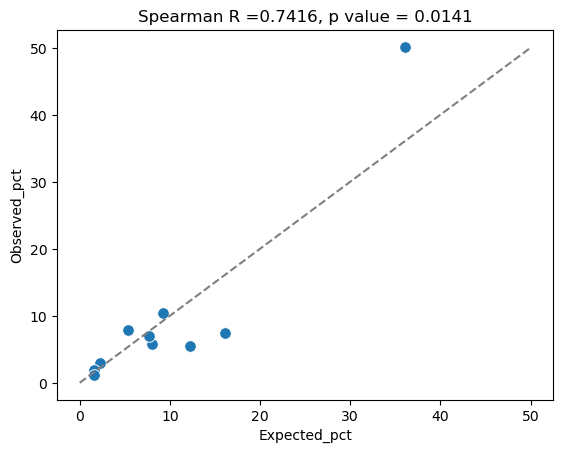

In [32]:
sns.scatterplot(data = pct, x = 'Expected_pct', y = 'Observed_pct', s=70)
plt.plot([0, 50], [0, 50], linestyle='--', color='gray')
plt.title(f'Spearman R ={r:.4f}, p value = {p:.4f}')
plt.savefig('../6-grammar_final/figs/fig28_celltype_corr.svg', format="svg")

# The END: SAVE

In [18]:
adata.write('../6-grammar_final/JCF-HT_annotated.h5ad')